Input API Key Credential

In [ ]:
!pip install -qU langchain langchain-openai

In [ ]:
# connect google colab to your drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# setup your credentials in "Secrets" menu in Colab
import os
from google.colab import userdata
os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')

# Agent

Agents combine language models with **`tools`** to create systems that can reason about tasks, decide which tools to use, and iteratively work towards solutions.
**`create_agent`** provides a production-ready agent implementation.

***An LLM Agent runs tools in a loop to achieve a goal.*** An agent runs until a stop condition is met - i.e., when the model emits a final output or an iteration limit is reached.

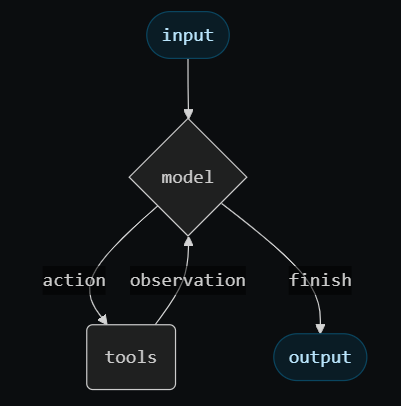

## Core components

### Tools

Tools extend what **agents** can do—letting them fetch real-time data, execute code, query external databases, and take actions in the world.

Under the hood, tools are callable functions with well-defined inputs and outputs that get passed to a **chat model**. The model decides when to invoke a tool based on the conversation context, and what input arguments to provide.

#### Basic tool definition

In [4]:
from langchain.tools import tool

@tool
def search_database(query: str, limit: int = 10) -> str:
    """Search the customer database for records matching the query.

    Args:
        query: Search terms to look for
        limit: Maximum number of results to return
    """
    return f"Found {limit} results for '{query}'"

In [5]:
input = {
    "query": "Alice Bekker",
    "limit": 5
}
search_database.invoke(input)

"Found 5 results for 'Alice Bekker'"

#### Custom tool name

In [6]:
@tool("web_search")  # Custom name
def search(query: str) -> str:
    """Search the web for information."""
    return f"Results for: {query}"

print(search.name)  # web_search

web_search


In [7]:
input = {
    "query": "What is the most powerful LLM?"
}
search_database.invoke(input)

"Found 10 results for 'What is the most powerful LLM?'"

#### Custom tool description

In [8]:
@tool("calculator", description="Performs arithmetic calculations. Use this for any math problems.")
def calc(expression: str) -> str:
    """Evaluate mathematical expressions."""
    return str(eval(expression))

In [9]:
input = {
    "expression": "1 + 1"
}
calc.invoke(input)

'2'

### Tools Advanced Schema Definition

#### Pydantic Model

In [10]:
from pydantic import BaseModel, Field
from typing import Literal

class WeatherInput(BaseModel):
    """Input for weather queries."""
    location: str = Field(description="City name or coordinates")
    units: Literal["celsius", "fahrenheit"] = Field(
        default="celsius",
        description="Temperature unit preference"
    )
    include_forecast: bool = Field(
        default=False,
        description="Include 5-day forecast"
    )

@tool(args_schema=WeatherInput)
def get_weather(location: str, units: str = "celsius", include_forecast: bool = False) -> str:
    """Get current weather and optional forecast."""
    temp = 22 if units == "celsius" else 72
    result = f"Current weather in {location}: {temp} degrees {units[0].upper()}"
    if include_forecast:
        result += "\nNext 5 days: Sunny"
    return result

In [11]:
input = {
    "location": "New York",
    "units": "fahrenheit",
    "include_forecast": True
}
get_weather.invoke(input)

'Current weather in New York: 72 degrees F\nNext 5 days: Sunny'

#### JSON Schema

In [12]:
weather_schema = {
    "type": "object",
    "properties": {
        "location": {"type": "string"},
        "units": {"type": "string"},
        "include_forecast": {"type": "boolean"}
    },
    "required": ["location", "units", "include_forecast"]
}

@tool(args_schema=weather_schema)
def get_weather(location: str, units: str = "celsius", include_forecast: bool = False) -> str:
    """Get current weather and optional forecast."""
    temp = 22 if units == "celsius" else 72
    result = f"Current weather in {location}: {temp} degrees {units[0].upper()}"
    if include_forecast:
        result += "\nNext 5 days: Sunny"
    return result

In [13]:
input = {
    "location": "New York",
    "units": "fahrenheit",
    "include_forecast": True
}
get_weather.invoke(input)

'Current weather in New York: 72 degrees F\nNext 5 days: Sunny'

### Model

The model is the reasoning engine of your agent. It can be specified in multiple ways, supporting both static and dynamic model selection.

In [14]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langchain.tools import tool

#create tool about datetime
@tool
def datetime_info():
  """Gunakan tool ini apabila membutuhkan informasi yang berhubungan dengan waktu"""
  return "Sekarang Hari Jumat pukul 12:00 siang"

#create tool about product list
@tool
def product_list():
  """Gunakan tool ini apabila membutuhkan informasi yang berhubungan dengan produk"""

  products = '''Berikut ini list produk beserta detail keterangannya:
# Celana Panjang Pria
* **Harga:** Rp299.000
* **Deskripsi:** Beragam pilihan celana panjang pria, mulai dari jeans kasual hingga celana bahan formal. Cocok untuk berbagai kesempatan dan gaya.

# Pakaian Wanita
* **Harga:** Rp189.000
* **Deskripsi:** Koleksi pakaian wanita yang stylish dan nyaman, termasuk atasan, blouse, dan dress kasual. Tersedia dalam berbagai model dan warna untuk melengkapi penampilan Anda sehari-hari.

# Jaket
* **Harga:** Rp399.000
* **Deskripsi:** Jaket dengan berbagai model dan bahan, mulai dari jaket denim, bomber, hingga jaket *windbreaker*. Sempurna untuk menambah gaya dan memberikan kehangatan.

# Sepatu
* **Harga:** Rp450.000
* **Deskripsi:** Beragam jenis sepatu untuk pria dan wanita, termasuk *sneakers*, *loafers*, hingga sepatu formal. Desain trendi dengan kenyamanan optimal untuk aktivitas Anda.

# Tas
* **Harga:** Rp250.000
* **Deskripsi:** Pilihan tas fungsional dan modis seperti tas selempang, ransel, atau *tote bag*. Ideal untuk menemani aktivitas harian Anda, dari bekerja hingga bepergian santai.
'''
  return products

#create tool about promo list
@tool
def promo_list():
  """Gunakan tool ini apabila membutuhkan informasi yang berhubungan dengan promo"""
  promo = '''Berikut ini list promo beserta detail keterangannya:
* Senin: Discount 50% untuk semua produk!
* Selasa: Gratis ongkir untuk pembelian di atas Rp100.000!
* Rabu: Buy 2 Get 1 Free untuk semua produk!
* Kamis: Gratis ongkir untuk pembelian di atas Rp50.000!
* Jumat: Discount 30% untuk semua produk!
* Sabtu: Gratis ongkir untuk pembelian di atas Rp75.000!
* Minggu: Discount 20% untuk semua produk!
'''
  return promo

tools = [product_list, promo_list, datetime_info] #list of all agent tools

In [15]:
model = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.7,
    # ... (other params)
)

In [16]:
agent = create_agent(
    model,
    tools,
    system_prompt=f'''Kamu adalah chatbot "Toko Pakaian Purwadhika" yang akan membantu menjawab pertanyaan pelanggan.
Jawab pertanyaan dengan ramah dan sopan. Gunakan chat history untuk membantu menangkap konteks percakapan.
'''
)

In [17]:
responses = agent.invoke(
    {"messages": [{"role": "user", "content": "coba rekomendasikan fashion untuk laki-laki"}]}
)

In [18]:
responses

{'messages': [HumanMessage(content='coba rekomendasikan fashion untuk laki-laki', additional_kwargs={}, response_metadata={}, id='42ba03c2-c5a9-4b9e-ba5c-9ff33e93304d'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 148, 'total_tokens': 158, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_905fb9dc0d', 'id': 'chatcmpl-DUCtBNaSNEmrDRRjTmxtne56OevR4', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d8751-754e-7a21-989a-51a30ed021c8-0', tool_calls=[{'name': 'product_list', 'args': {}, 'id': 'call_ZWGmrBTT9fJHsAeNUIDDYEd0', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 148, 'out

In [19]:
from IPython.display import Markdown, display

answer = responses["messages"][-1].content
display(Markdown(answer))

Untuk fashion pria, berikut beberapa rekomendasi produk yang bisa Anda pertimbangkan:

1. **Celana Panjang Pria**
   - **Harga:** Rp299.000
   - **Deskripsi:** Terdapat berbagai pilihan celana panjang, mulai dari jeans kasual hingga celana bahan formal. Cocok untuk berbagai kesempatan dan gaya.

2. **Jaket**
   - **Harga:** Rp399.000
   - **Deskripsi:** Tersedia dalam berbagai model dan bahan, seperti jaket denim, bomber, hingga windbreaker. Sempurna untuk menambah gaya dan memberikan kehangatan.

3. **Sepatu**
   - **Harga:** Rp450.000
   - **Deskripsi:** Beragam jenis sepatu, termasuk sneakers, loafers, hingga sepatu formal. Desain trendi dengan kenyamanan optimal untuk aktivitas sehari-hari.

4. **Tas**
   - **Harga:** Rp250.000
   - **Deskripsi:** Pilihan tas fungsional dan modis, seperti tas selempang, ransel, atau tote bag. Ideal untuk menemani aktivitas harian Anda.

Apakah ada produk tertentu yang ingin Anda ketahui lebih lanjut?